# Part 3 Transfer Learning Report

Run folder: `baseline_v2`

This notebook loads the saved run artifacts, rebuilds pandas tables from the JSON files, and includes cells you can adjust and rerun.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, display

PROJECT_ROOT = Path(r"C:\Users\emil_\vscode\Assignment1")
RUN_DIR = Path(r"C:\Users\emil_\vscode\Assignment1\Part3\outputs\scratch_improvement_2026-04-29_073549\baseline_v2")
CONFIG_PATH = RUN_DIR / 'config.json'
SUMMARY_PATH = RUN_DIR / 'summary.json'
HISTORY_PATH = RUN_DIR / 'training_history.json'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Part3.part3_finetuning_external_models import build_data_loaders, denormalize_image

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

config = load_json(CONFIG_PATH)
summary = load_json(SUMMARY_PATH)
history = load_json(HISTORY_PATH)
print(f'Loaded run: {RUN_DIR.name}')

Loaded run: baseline_v2


## Config And Summary

In [2]:
config_df = pd.DataFrame([
    {'field': key, 'value': value}
    for key, value in config.items()
])
summary_df = pd.DataFrame([
    {'metric': key, 'value': value}
    for key, value in summary.items()
])
config_df

,field,value
0,task_name,oxford_pet_cat_vs_dog
1,label_mode,species
2,class_names,"[cat, dog]"
3,breed_count,37
4,breed_names_preview,"[abyssinian, american bulldog, american pit bu..."
5,model_name,scratch_cnn_improved
6,backbone_name,baseline_v2
7,transfer_learning,False
8,weights_name,None
9,variant_name,baseline_v2


In [3]:
summary_df

,metric,value
0,best_epoch,24
1,best_stage,scratch_improved
2,selection_metric,validation_accuracy
3,best_validation_accuracy,0.872283
4,best_validation_loss_at_best_epoch,0.389636
5,best_epoch_by_loss,24
6,best_validation_loss,0.389636
7,time_to_best_model_seconds,691.438761
8,total_training_time_seconds,720.530102
9,average_epoch_time_seconds,28.780061


## Epoch History

In [4]:
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = 'epoch'
history_df

,train_loss,train_accuracy,val_loss,val_accuracy,epoch_duration_seconds,learning_rate,stage
epoch,,,,,,,
1,0.625499,0.667271,0.624740,0.687500,33.776501,0.000300,scratch_improved
2,0.613868,0.675121,0.610284,0.692935,28.446485,0.000299,scratch_improved
3,0.607411,0.682065,0.606004,0.684783,27.928224,0.000295,scratch_improved
4,0.596049,0.690821,0.592323,0.673913,28.050921,0.000289,scratch_improved
5,0.594241,0.695350,0.593316,0.695652,28.929026,0.000281,scratch_improved
6,0.583901,0.699577,0.652940,0.698370,29.634464,0.000271,scratch_improved
7,0.574958,0.705918,0.602191,0.709239,28.593401,0.000259,scratch_improved
8,0.569631,0.722222,0.615884,0.641304,28.839821,0.000246,scratch_improved
9,0.556619,0.735507,0.629690,0.649457,28.313594,0.000230,scratch_improved


## Metric Curves From JSON

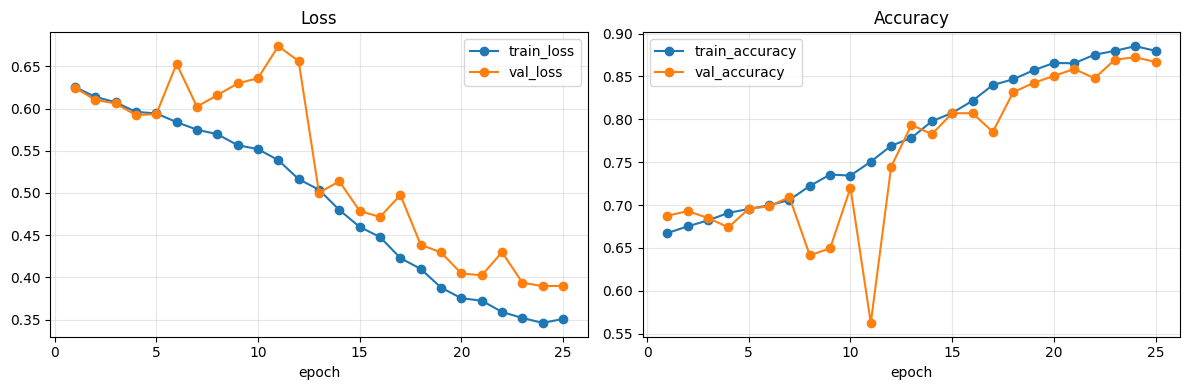

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[['train_loss', 'val_loss']].plot(ax=axes[0], marker='o', title='Loss')
history_df[['train_accuracy', 'val_accuracy']].plot(ax=axes[1], marker='o', title='Accuracy')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rebuild The Dataset

In [6]:
data_bundle = build_data_loaders(
    dataset_root=Path(config['dataset_root']),
    batch_size=config['batch_size'],
    validation_ratio=config['validation_ratio'],
    test_ratio=config['test_ratio'],
    seed=config['seed'],
    num_workers=config.get('num_workers', 0),
)
pd.DataFrame([
    {'split': 'train', 'samples': data_bundle['train_size']},
    {'split': 'validation', 'samples': data_bundle['val_size']},
    {'split': 'test', 'samples': data_bundle['test_size']},
])

,split,samples
0,train,3312
1,validation,368
2,test,3669


## Preview A Training Batch

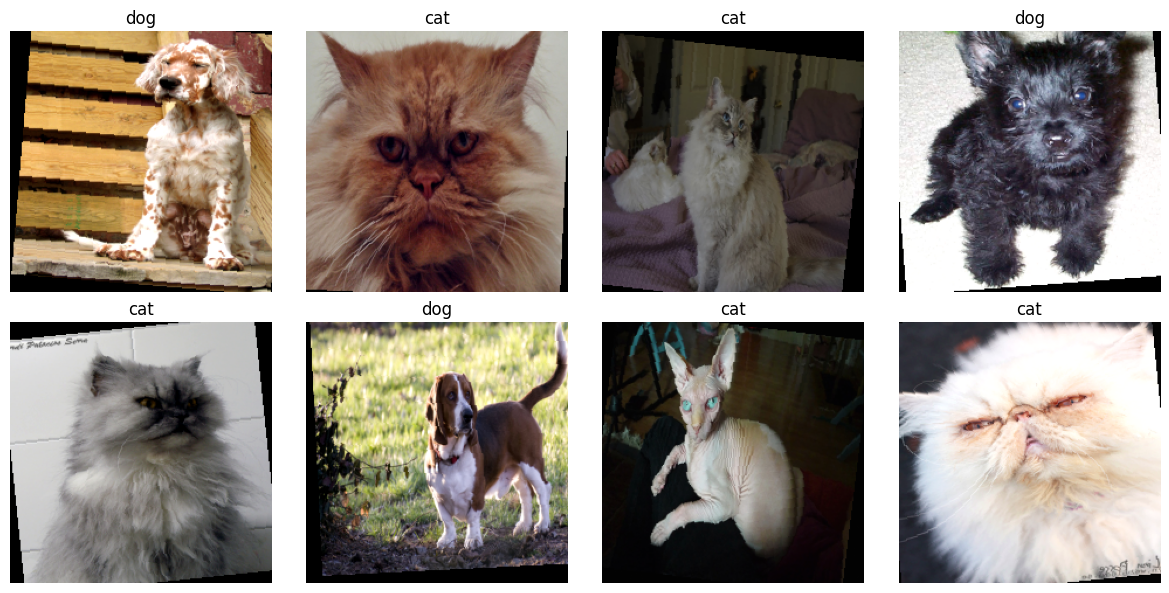

In [7]:
images, labels = next(iter(data_bundle['train_loader']))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for axis in axes:
    axis.axis('off')
for index in range(min(8, len(images))):
    axes[index].imshow(denormalize_image(images[index]))
    axes[index].set_title(data_bundle['class_names'][int(labels[index])])
plt.tight_layout()
plt.show()

## Saved Artifacts


### loss_curve.png


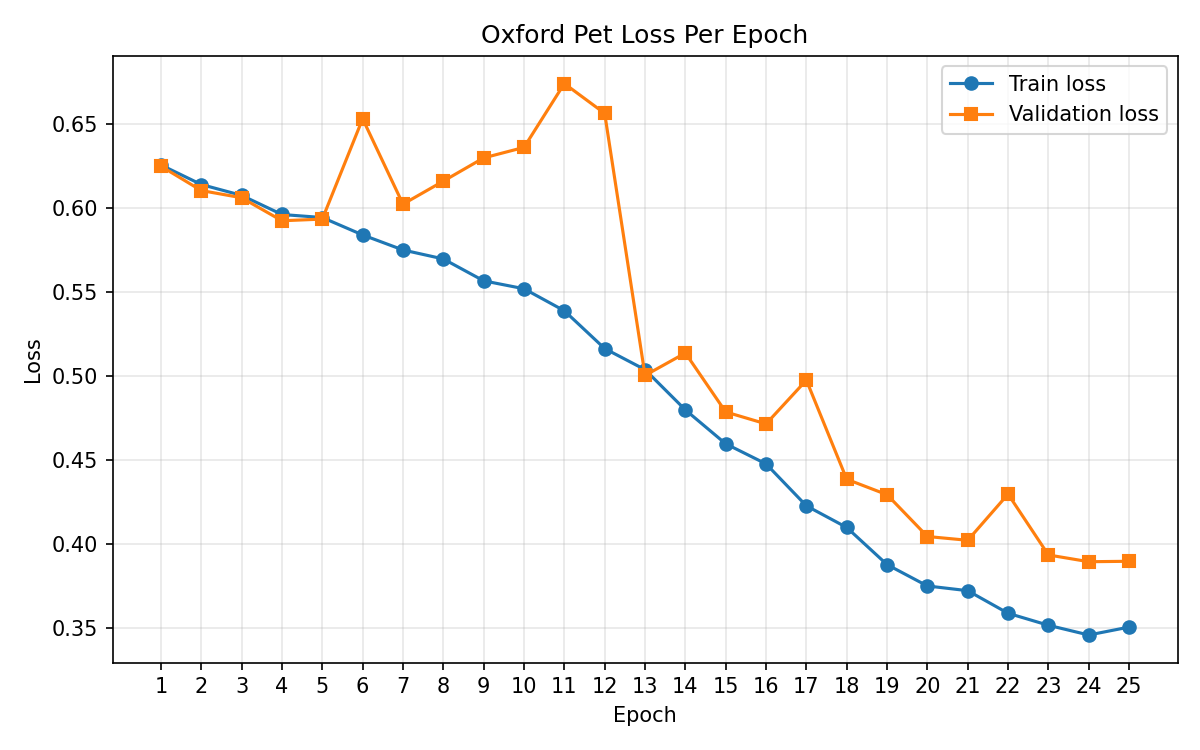


### accuracy_curve.png


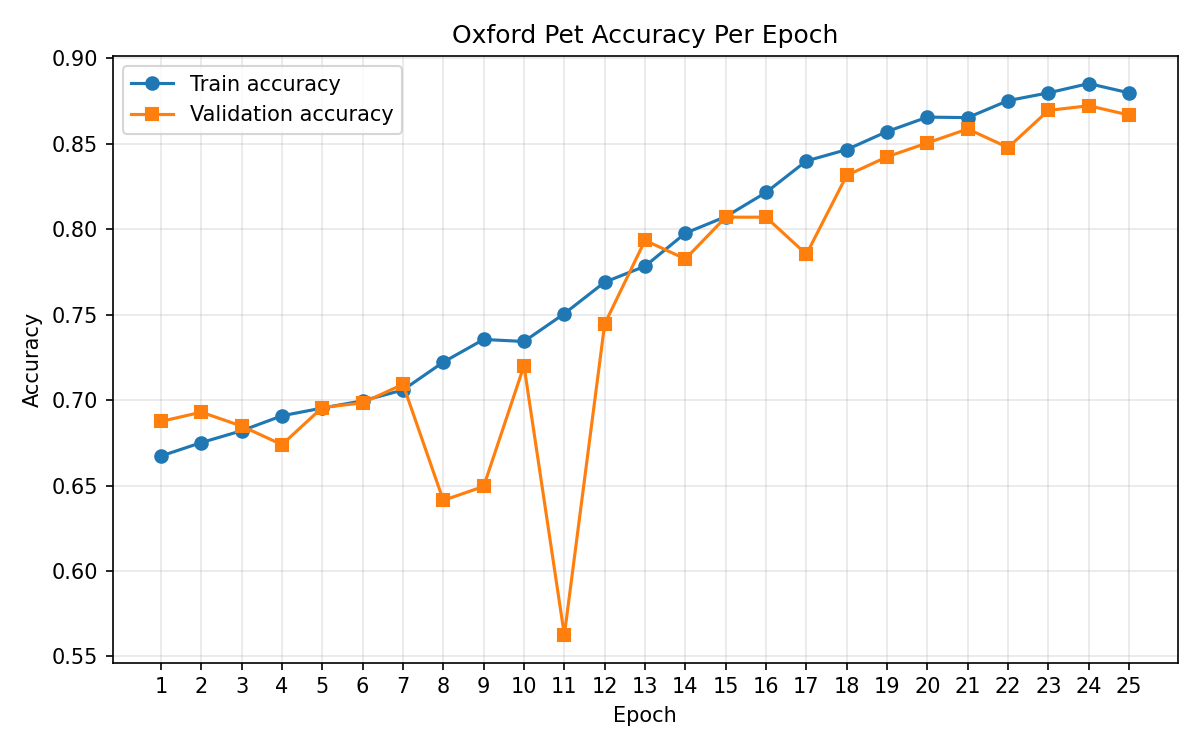


### confusion_matrix.png


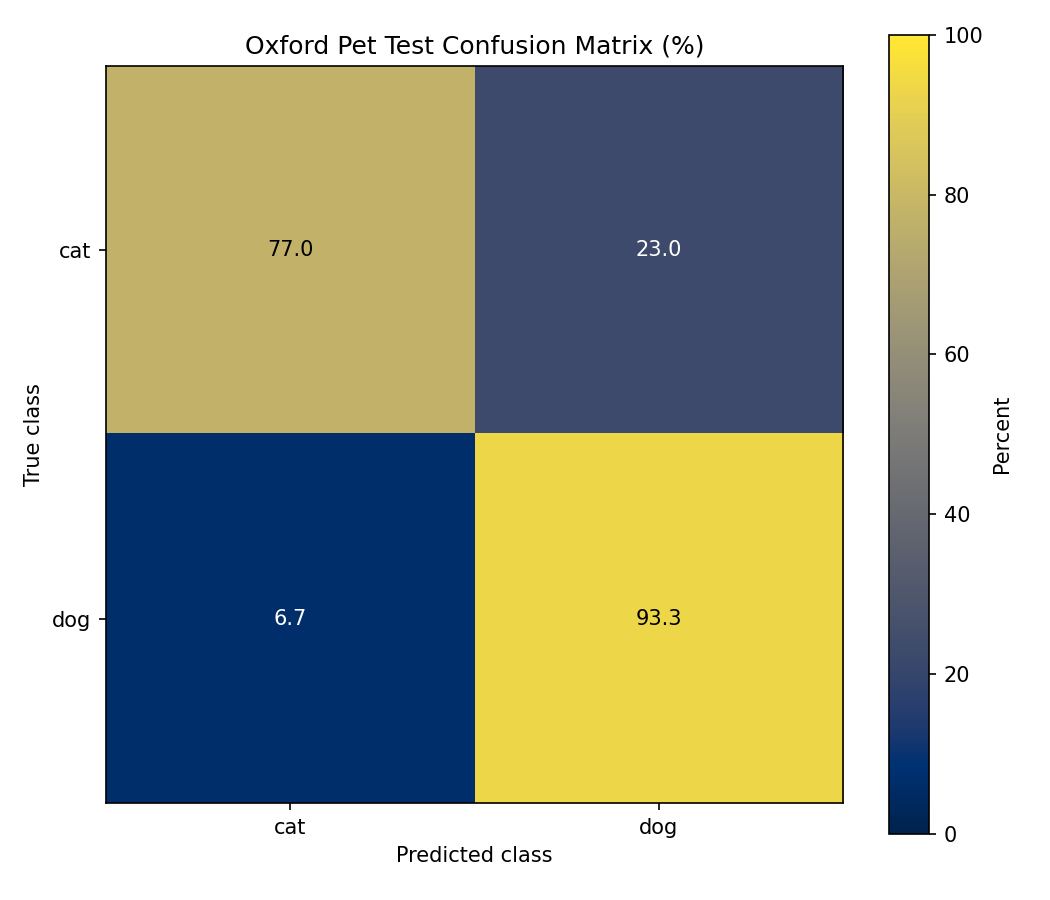


### correct_predictions.png


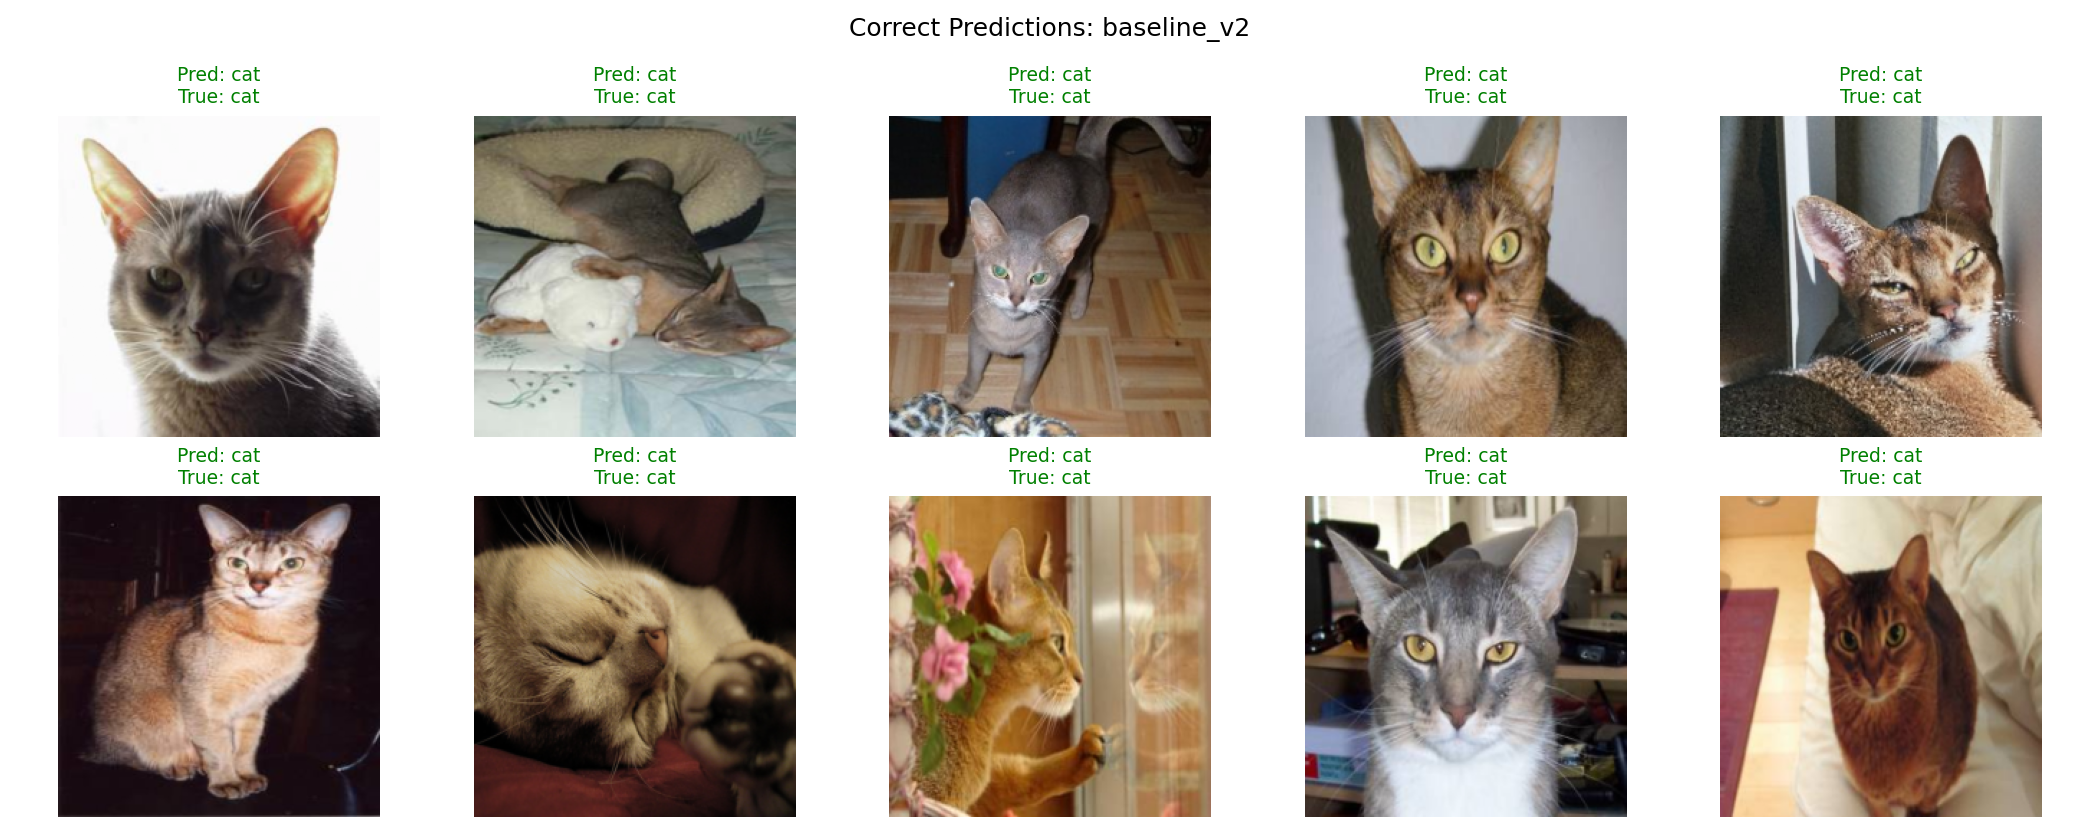


### incorrect_predictions.png


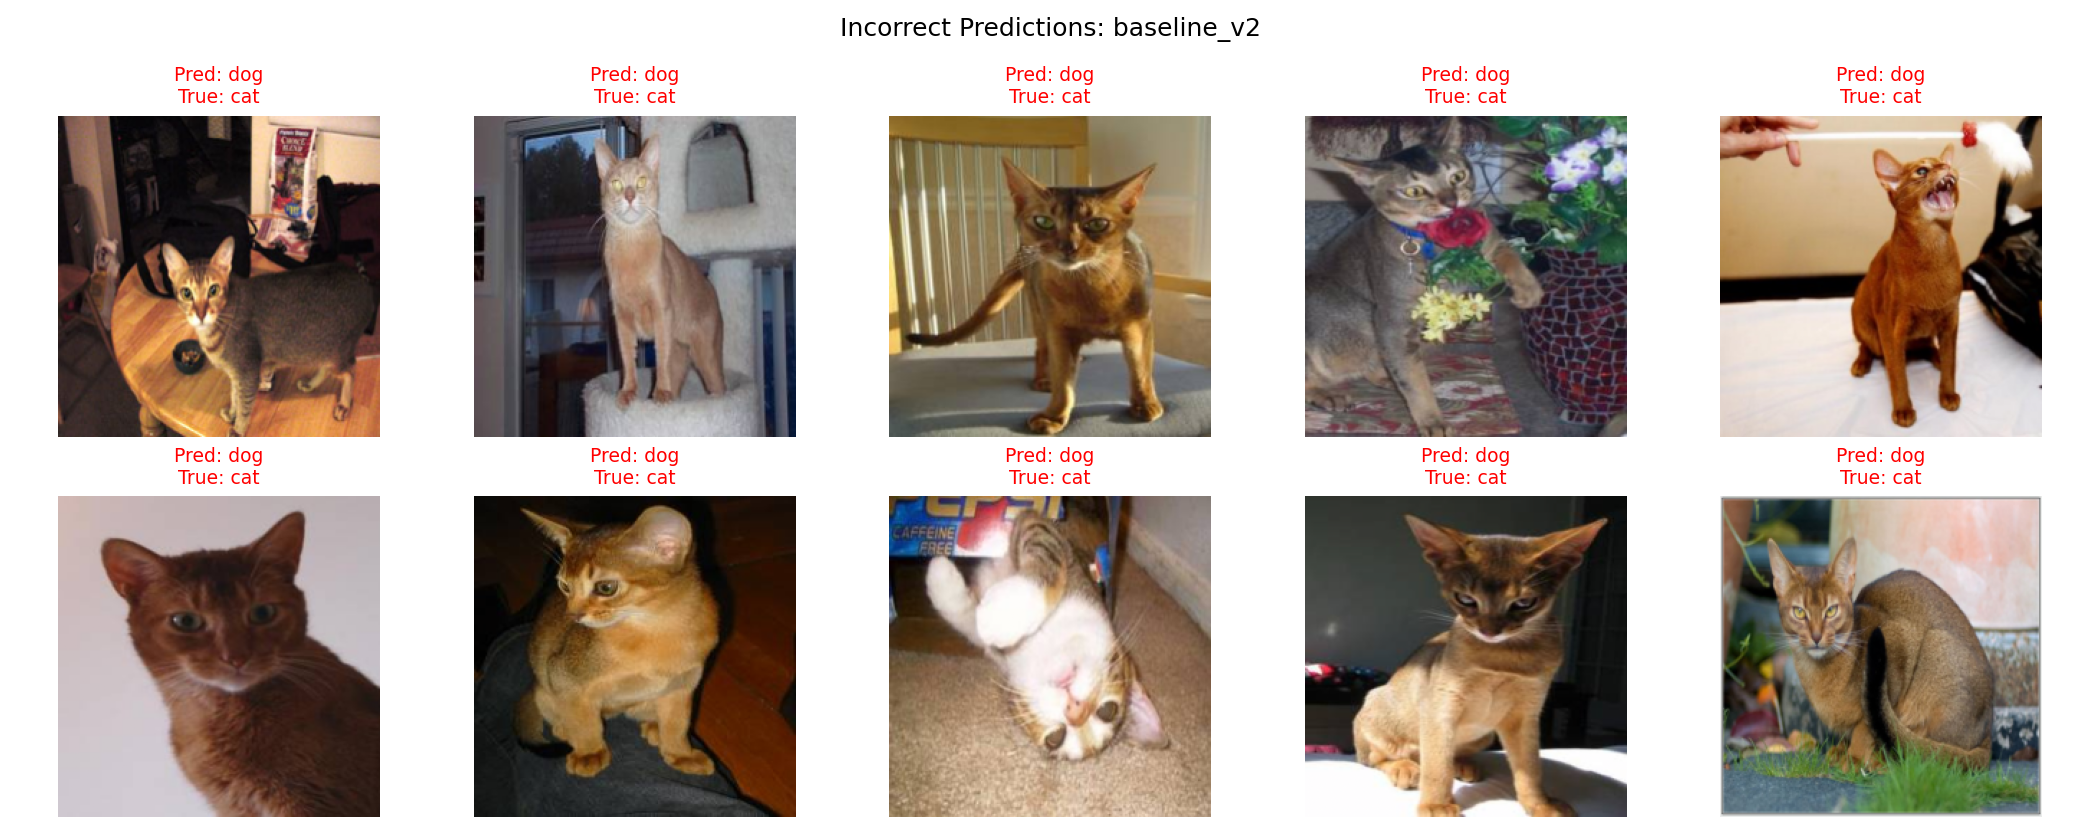

In [8]:
plot_files = [
    'loss_curve.png',
    'accuracy_curve.png',
    'confusion_matrix.png',
    'correct_predictions.png',
    'incorrect_predictions.png',
]
for plot_name in plot_files:
    plot_path = RUN_DIR / plot_name
    print(f'\n### {plot_name}')
    if plot_path.exists():
        display(Image(filename=str(plot_path)))
    else:
        print('Missing:', plot_path)

## Re-Run This Experiment

In [9]:
from argparse import Namespace
from Part3.part3_finetuning_external_models import run_experiment

# Uncomment to rerun into a new folder.
# rerun_args = Namespace(
#     model=config['model_name'],
#     dataset_root=config['dataset_root'],
#     batch_size=config['batch_size'],
#     epochs_head=config['epochs_head'],
#     epochs_finetune=config['epochs_finetune'],
#     learning_rate_head=config['learning_rate_head'],
#     learning_rate_finetune=config['learning_rate_finetune'],
#     validation_ratio=config['validation_ratio'],
#     test_ratio=config['test_ratio'],
#     seed=config['seed'],
#     output_dir=str(RUN_DIR.parent / f'{RUN_DIR.name}_rerun'),
#     checkpoint_interval=config['checkpoint_interval'],
#     num_workers=config.get('num_workers', 0),
# )
# run_experiment(rerun_args)